In [85]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.linear_model import LinearRegression, Lasso, LassoCV

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Two groups of features to explore

In [2]:
features_with_liq = [
    "LOG_LIQ",
    "EDUC",
    "LOG_INCOME",
    "HHOUSES",
    "AGE",
    "FINLIT",
    "EMERGSAV",
    "KIDS",
    "MARRIED",
    "OCCAT1",
    "YESFINRISK",
    "LOG_DEBT",
    "SPENDMOR",
    "LATE"
]

features_without_liq = [
    "EDUC",
    "LOG_INCOME",
    "HHOUSES",
    "AGE",
    "FINLIT",
    "EMERGSAV",
    "KIDS",
    "MARRIED",
    "OCCAT1",
    "YESFINRISK",
    "LOG_DEBT",
    "SPENDMOR",
    "LATE"
]

In [3]:
def assign_age_group(age):
    """
    Assigns a respondent to an age group based on their age.

    Parameters:
        age (int or float): The respondent's age.

    Returns:
        str: The age group label used for retirement readiness analysis.
    """
    if age < 30:
        return "Under 30"
    elif age < 40:
        return "30-39"
    elif age < 50:
        return "40-49"
    elif age < 60:
        return "50-59"
    elif age < 65:
        return "60-64"
    else:
        return "65+"
    

def retirement_multiplier(age):
    """
    Returns the retirement savings multiplier associated with a respondent's age.

    The multiplier represents the estimated amount of retirement liquidity
    a respondent should have saved as a multiple of annual income for their
    age group. These thresholds are intentionally moderate because the measure
    focuses only on retirement liquidity, not total net worth, Social Security,
    pensions, or home equity.

    Parameters:
        age (int or float): The respondent's age.

    Returns:
        float: The retirement readiness multiplier for the respondent's age group.
    """
    if age < 30:
        return 0.25
    elif age < 40:
        return 0.75
    elif age < 50:
        return 2
    elif age < 60:
        return 4
    elif age < 65:
        return 6
    else:
        return 8

Because the dependent variable focuses specifically on retirement liquidity rather than total household wealth, moderate age-adjusted income multiples were used to avoid overstating retirement risk. The thresholds still increase by age group, but they are lower than full retirement savings benchmarks that often assume broader measures of wealth, pensions, Social Security, or home equity.

In [4]:
df = pd.read_csv('../data/processed/Cleaned_SCF_2022.csv', index_col=0)
df.shape

(4595, 15)

In [5]:
df.head()

,LOG_LIQ,EDUC,LOG_INCOME,HHOUSES,AGE,FINLIT,EMERGSAV,KIDS,MARRIED,OCCAT1,YESFINRISK,LOG_DEBT,SPENDMOR,LATE,LOG_RET_ASSETS
0,9.480444,9,10.566323,1,70,1,1,2,2,3,0,12.180760,5,0,13.128546
5,10.609082,12,12.323103,1,46,3,1,0,2,2,0,13.159083,3,0,12.390480
10,9.295692,14,13.006586,1,68,3,1,0,1,3,0,16.682273,3,1,17.925595
15,12.007628,12,11.934327,0,74,3,1,0,2,3,0,0.000000,3,0,15.113520
20,7.003974,8,10.936822,0,19,0,0,0,1,1,0,9.305741,2,0,7.003974


In [6]:
df.columns

Index(['LOG_LIQ', 'EDUC', 'LOG_INCOME', 'HHOUSES', 'AGE', 'FINLIT', 'EMERGSAV',
       'KIDS', 'MARRIED', 'OCCAT1', 'YESFINRISK', 'LOG_DEBT', 'SPENDMOR',
       'LATE', 'LOG_RET_ASSETS'],
      dtype='str')

verify age group and multiplier are working as expected

In [7]:
df["AGE_GROUP"] = df["AGE"].apply(assign_age_group)
df["RET_MULTIPLIER"] = df["AGE"].apply(retirement_multiplier)

df[["AGE", "AGE_GROUP", "RET_MULTIPLIER"]].head()

,AGE,AGE_GROUP,RET_MULTIPLIER
0,70,65+,8.00
5,46,40-49,2.00
10,68,65+,8.00
15,74,65+,8.00
20,19,Under 30,0.25


create classification target

In [8]:
# convert log-transformed variables back to raw dollar estimates
df["INCOME_RAW_EST"] = np.expm1(df["LOG_INCOME"])
df["RET_ASSETS_RAW_EST"] = np.expm1(df["LOG_RET_ASSETS"])
df["DEBT_RAW_EST"] = np.expm1(df["LOG_DEBT"])

# create age-adjusted retirement readiness threshold
df["RET_READY_THRESHOLD"] = df["INCOME_RAW_EST"] * df["RET_MULTIPLIER"]

# create classification target
# rule1: if income > 0, compare retirement assets to the age-adjusted income threshold
# rule2: if income == 0, classify as ready only if retirement assets exceed debt
df["RET_READY"] = np.where(
    df["INCOME_RAW_EST"] > 0,
    np.where(
        df["RET_ASSETS_RAW_EST"] >= df["RET_READY_THRESHOLD"],
        1,
        0
    ),
    np.where(
        df["LOG_RET_ASSETS"] > df["LOG_DEBT"],
        1,
        0
    )
)

verify classification is working

In [9]:
df[[
    "AGE",
    "AGE_GROUP",
    "RET_MULTIPLIER",
    "INCOME_RAW_EST",
    "RET_ASSETS_RAW_EST",
    "DEBT_RAW_EST",
    "RET_READY_THRESHOLD",
    "RET_READY"
]].head(20)

,AGE,AGE_GROUP,RET_MULTIPLIER,INCOME_RAW_EST,RET_ASSETS_RAW_EST,DEBT_RAW_EST,RET_READY_THRESHOLD,RET_READY
0,70,65+,8.00,3.880473e+04,503100.0,195000.0,3.104379e+05,1
5,46,40-49,2.00,2.248297e+05,240500.0,518700.0,4.496593e+05,0
10,68,65+,8.00,4.453357e+05,60951890.0,17580000.0,3.562685e+06,1
15,74,65+,8.00,1.524086e+05,3662000.0,0.0,1.219269e+06,1
20,19,Under 30,0.25,5.620741e+04,1100.0,11000.0,1.405185e+04,0
25,74,65+,8.00,2.831989e+05,6523000.0,111000.0,2.265591e+06,1
30,52,50-59,4.00,1.343573e+07,15166300.0,0.0,5.374294e+07,0
35,60,60-64,6.00,3.999374e+04,1500.0,0.0,2.399624e+05,0
40,43,40-49,2.00,6.701653e+05,295000.0,925000.0,1.340331e+06,0
45,67,65+,8.00,4.323647e+04,27950.0,183400.0,3.458918e+05,0


In [10]:
df["RET_READY"].value_counts()

RET_READY
0    2997
1    1598
Name: count, dtype: int64

In [11]:
df["RET_READY"].value_counts(normalize=True).round(3)

RET_READY
0    0.652
1    0.348
Name: proportion, dtype: float64

The age-adjusted retirement readiness target classified approximately 34.8% of respondents as retirement ready and 65.2% as not retirement ready. This indicates that the classification target is imbalanced, so later classification models should be evaluated using precision, recall, F1-score, and possibly class-weighted models instead of relying on accuracy alone.

## Baseline Model

In [12]:
regression_features = [
    # financial
    "LOG_LIQ",
    "LOG_INCOME",
    "LOG_DEBT",

    # socioeconomic / behavioral
    "EDUC",
    "FINLIT",
    "AGE",
    "HHOUSES",
    "EMERGSAV",
    "MARRIED",
    "KIDS",
    "OCCAT1",
    "LATE",
    "SPENDMOR",
    "YESFINRISK"
]

target = 'LOG_RET_ASSETS'

In [13]:
X = df[regression_features]
y = df[target]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3676, 14), (919, 14), (3676,), (919,))

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = lr.predict(X_test)

In [18]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression")
print("R²:", r2)
print("RMSE:", rmse)

Baseline Linear Regression
R²: 0.8055757121627284
RMSE: 1.7084465094764254


In [19]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

pipeline.fit(X_train, y_train)
coefs = pipeline.named_steps['lr'].coef_.ravel()
coefficients = pd.Series(coefs, index=X.columns).sort_values(ascending=False)
coefficients

LOG_LIQ       2.459385
LOG_INCOME    0.502485
EDUC          0.482724
HHOUSES       0.341103
AGE           0.326679
FINLIT        0.216539
EMERGSAV      0.187573
LOG_DEBT      0.031869
LATE          0.024778
YESFINRISK    0.017098
SPENDMOR     -0.036484
MARRIED      -0.115244
KIDS         -0.115325
OCCAT1       -0.159009
dtype: float64

### Lasso  

In [20]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01, random_state=42, max_iter=10_000))
])

In [21]:
lasso_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [22]:
y_pred_lasso = lasso_pipeline.predict(X_test)

In [23]:
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso Regression")
print("R²:", r2_lasso)
print("RMSE:", rmse_lasso)

Lasso Regression
R²: 0.8054950814369988
RMSE: 1.708800732203236


In [24]:
lasso_coefs = pd.Series(
    lasso_pipeline.named_steps["lasso"].coef_,
    index=X.columns
).sort_values(ascending=False)

lasso_coefs

LOG_LIQ       2.462482
LOG_INCOME    0.502594
EDUC          0.479355
HHOUSES       0.339997
AGE           0.310005
FINLIT        0.211761
EMERGSAV      0.181467
LOG_DEBT      0.023977
LATE          0.010469
YESFINRISK    0.006685
SPENDMOR     -0.026113
KIDS         -0.103487
MARRIED      -0.108361
OCCAT1       -0.142844
dtype: float64

In [25]:
lasso_summary = pd.DataFrame({
    "Feature": lasso_coefs.index,
    "Coefficient": lasso_coefs.values,
    "Direction": np.where(lasso_coefs.values > 0, "Positive", 
                          np.where(lasso_coefs.values < 0, "Negative", "Removed"))
})

lasso_summary

,Feature,Coefficient,Direction
0,LOG_LIQ,2.462482,Positive
1,LOG_INCOME,0.502594,Positive
2,EDUC,0.479355,Positive
3,HHOUSES,0.339997,Positive
4,AGE,0.310005,Positive
5,FINLIT,0.211761,Positive
6,EMERGSAV,0.181467,Positive
7,LOG_DEBT,0.023977,Positive
8,LATE,0.010469,Positive
9,YESFINRISK,0.006685,Positive


The baseline Linear Regression model performed strongly, explaining approximately 80.6% of the variation in `LOG_RET_ASSETS`. The strongest positive predictors were liquidity, income, education, homeownership, age, financial literacy, and emergency savings. This suggests that retirement-relevant assets are closely associated with both financial resources and household-level socioeconomic factors.

The Lasso Regression model produced nearly identical performance, with an R² of approximately 0.805 and an RMSE of approximately 1.709. Because Lasso applies regularization, the similar performance suggests that the selected feature set is stable and that the baseline model is not substantially overfitting. Lasso also confirmed that `LOG_LIQ`, `LOG_INCOME`, education, homeownership, age, financial literacy, and emergency savings were the most meaningful positive predictors, while children, marital status, and occupation category had negative coefficients.

The large positive coefficient for `LOG_LIQ` supports the importance of liquidity in retirement readiness, while the much smaller coefficient for `LOG_DEBT` suggests that debt had a weaker relationship with retirement-relevant assets after controlling for other factors.

In [26]:
lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=42, max_iter=10_000))
])

lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.named_steps['lasso'].alpha_
print("Best alpha:", best_alpha)

Best alpha: 0.011409359639284243


### Simplified Regression Model

In [27]:
reduced_features = [
    "LOG_LIQ",      # greatest predictor
    "LOG_INCOME",   # strong 
    "LOG_DEBT",     # RQs
    "EDUC",         # strong
    "HHOUSES",      # strong
    "AGE",          # needed for life stages
    "FINLIT",       # RQs
    "EMERGSAV"      # RQs
]

X_reduced = df[reduced_features]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

reduced_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

reduced_pipeline.fit(X_train_r, y_train_r)

y_pred_r = reduced_pipeline.predict(X_test_r)

r2_reduced = r2_score(y_test_r, y_pred_r)
rmse_reduced = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print("Reduced Linear Regression Model")
print("R²:", r2_reduced)
print("RMSE:", rmse_reduced)

Reduced Linear Regression Model
R²: 0.8009813393134628
RMSE: 1.7285144999543016


In [28]:
reduced_coefs = pd.Series(
    reduced_pipeline.named_steps["lr"].coef_,
    index=X_reduced.columns
).sort_values(ascending=False)

reduced_coefs

LOG_LIQ       2.484340
LOG_INCOME    0.539913
EDUC          0.488893
HHOUSES       0.347592
AGE           0.276000
FINLIT        0.226698
EMERGSAV      0.192638
LOG_DEBT      0.053753
dtype: float64

In [29]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Lasso Regression",
        "Simplified Linear Regression"
    ],
    "R2": [
        r2,
        r2_lasso,
        r2_reduced
    ],
    "RMSE": [
        rmse,
        rmse_lasso,
        rmse_reduced
    ]
})

model_comparison

,Model,R2,RMSE
0,Baseline Linear Regression,0.805576,1.708447
1,Lasso Regression,0.805495,1.708801
2,Simplified Linear Regression,0.800981,1.728514


The three regression models produced very similar results, suggesting that the selected predictors are stable across modeling approaches. The baseline Linear Regression model explained approximately 80.6% of the variation in `LOG_RET_ASSETS`, while the Lasso Regression model performed nearly the same with an R² of approximately 0.805. This indicates that regularization did not substantially improve performance, but it did confirm the importance of the selected features.

The simplified Linear Regression model also performed strongly, with an R² of approximately 0.801 and an RMSE of approximately 1.728. Although its performance was slightly lower than the full baseline model, the difference was small. This suggests that the simplified feature set captures most of the predictive value while being easier to interpret. Across the models, liquidity, income, education, homeownership, age, financial literacy, and emergency savings were the most meaningful predictors of retirement-relevant assets.

# Classification

## Age-Adjusted Retirement Readiness Classification

This section uses the age-adjusted retirement readiness target created earlier in the notebook. Unlike the regression models, which predict logged retirement liquidity, this classification model predicts whether a respondent is retirement ready or at risk based on the binary RET_READY variable.

In [30]:
classification_features = features_with_liq

classification_target = "RET_READY"

In [31]:
X_cls = df[classification_features]
y_cls = df[classification_target]

In [32]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

X_train_cls.shape, X_test_cls.shape, y_train_cls.shape, y_test_cls.shape

((3676, 14), (919, 14), (3676,), (919,))

In [33]:
print("Training target balance:")
print(y_train_cls.value_counts(normalize=True).round(3))

print("\nTesting target balance:")
print(y_test_cls.value_counts(normalize=True).round(3))

Training target balance:
RET_READY
0    0.652
1    0.348
Name: proportion, dtype: float64

Testing target balance:
RET_READY
0    0.652
1    0.348
Name: proportion, dtype: float64


Logistic Regression Classifier

In [34]:
log_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=10_000,
        class_weight="balanced",
        random_state=42
    ))
])

log_clf.fit(X_train_cls, y_train_cls)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [35]:
y_pred_log = log_clf.predict(X_test_cls)

print("Logistic Regression Classification Results")
print(classification_report(y_test_cls, y_pred_log, zero_division=0))

Logistic Regression Classification Results
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       599
           1       0.62      0.79      0.69       320

    accuracy                           0.76       919
   macro avg       0.74      0.76      0.75       919
weighted avg       0.78      0.76      0.76       919



In [36]:
cm_log = confusion_matrix(y_test_cls, y_pred_log)

cm_log_df = pd.DataFrame(
    cm_log,
    index=["Actual Not Ready", "Actual Ready"],
    columns=["Predicted Not Ready", "Predicted Ready"]
)

cm_log_df

,Predicted Not Ready,Predicted Ready
Actual Not Ready,443,156
Actual Ready,68,252


The Logistic Regression classifier achieved an overall accuracy of approximately 76% when predicting retirement readiness. The model performed better at identifying respondents who were not retirement ready, with precision of 0.87 and recall of 0.74 for class 0. For respondents classified as retirement ready, the model achieved recall of 0.79, meaning it correctly identified most ready respondents, but precision was lower at 0.62, indicating that some not-ready respondents were incorrectly classified as ready.

The confusion matrix shows that the model correctly classified 443 not-ready respondents and 252 ready respondents. However, it also misclassified 156 not-ready respondents as ready and 68 ready respondents as not ready. Overall, the model provides a reasonable baseline classification result, but the false positives suggest that additional model tuning or alternative classifiers may improve the reliability of retirement-readiness predictions.

Because the project focuses on identifying households at risk of not being retirement ready, recall for the not-ready class is especially important. The model correctly identified 74% of not-ready respondents, but the 156 false positives indicate that some at-risk households were still missed by being classified as ready.

### Random Forest Classifier

In [37]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=None
)

rf_clf.fit(X_train_cls, y_train_cls)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

The Random Forest classifier was evaluated as a nonlinear alternative to logistic regression. Because the retirement readiness target was highly imbalanced, class-specific precision, recall, and F1-score were used in addition to overall accuracy. The performance of the Random Forest model was compared against the logistic regression model to determine whether the nonlinear model improved identification of retirement-ready respondents.

In [38]:
y_pred_rf = rf_clf.predict(X_test_cls)

print("Random Forest Classification Results")
print(classification_report(y_test_cls, y_pred_rf, zero_division=0))

Random Forest Classification Results
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       599
           1       0.71      0.55      0.62       320

    accuracy                           0.76       919
   macro avg       0.75      0.71      0.72       919
weighted avg       0.76      0.76      0.76       919



In [39]:
cm_rf = confusion_matrix(y_test_cls, y_pred_rf)

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=["Actual Not Ready", "Actual Ready"],
    columns=["Predicted Not Ready", "Predicted Ready"]
)

cm_rf_df

,Predicted Not Ready,Predicted Ready
Actual Not Ready,528,71
Actual Ready,145,175


In [40]:
rf_importance = pd.Series(
    rf_clf.feature_importances_,
    index=classification_features
).sort_values(ascending=False)

rf_importance

LOG_LIQ       0.246032
LOG_INCOME    0.174165
AGE           0.124243
EDUC          0.110174
LOG_DEBT      0.106482
SPENDMOR      0.047512
FINLIT        0.044953
KIDS          0.033109
OCCAT1        0.030068
EMERGSAV      0.027360
HHOUSES       0.019272
MARRIED       0.017146
YESFINRISK    0.009797
LATE          0.009686
dtype: float64

In [41]:
classification_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test_cls, y_pred_log),
        accuracy_score(y_test_cls, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test_cls, y_pred_log, zero_division=0),
        precision_score(y_test_cls, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test_cls, y_pred_log, zero_division=0),
        recall_score(y_test_cls, y_pred_rf, zero_division=0)
    ],
    "F1": [
        f1_score(y_test_cls, y_pred_log, zero_division=0),
        f1_score(y_test_cls, y_pred_rf, zero_division=0)
    ]
})

classification_model_comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.756257,0.617647,0.787500,0.692308
1,Random Forest,0.764962,0.711382,0.546875,0.618375


Logistic Regression and Random Forest produced similar accuracy scores, both around 76%. Logistic Regression had stronger recall for the retirement-ready class, correctly identifying 79% of ready respondents. Random Forest had stronger recall for the not-ready class, correctly identifying 88% of not-ready respondents. Because this project focuses on identifying households at risk of not being retirement ready, the Random Forest model may be more useful even though its recall for ready respondents was lower. This suggests that Random Forest is better at minimizing cases where at-risk households are incorrectly classified as ready.

### Gradient Boosting Classifier

In [42]:
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train_cls, y_train_cls)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [43]:
y_pred_gb = gb_clf.predict(X_test_cls)

print("Gradient Boosting Classification Results")
print(classification_report(y_test_cls, y_pred_gb, zero_division=0))

Gradient Boosting Classification Results
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       599
           1       0.71      0.59      0.64       320

    accuracy                           0.77       919
   macro avg       0.76      0.73      0.74       919
weighted avg       0.77      0.77      0.77       919



In [44]:
cm_gb = confusion_matrix(y_test_cls, y_pred_gb)

cm_gb_df = pd.DataFrame(
    cm_gb,
    index=["Actual Not Ready", "Actual Ready"],
    columns=["Predicted Not Ready", "Predicted Ready"]
)

cm_gb_df

,Predicted Not Ready,Predicted Ready
Actual Not Ready,523,76
Actual Ready,132,188


In [45]:
classification_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test_cls, y_pred_log),
        accuracy_score(y_test_cls, y_pred_rf),
        accuracy_score(y_test_cls, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test_cls, y_pred_log, zero_division=0),
        precision_score(y_test_cls, y_pred_rf, zero_division=0),
        precision_score(y_test_cls, y_pred_gb, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test_cls, y_pred_log, zero_division=0),
        recall_score(y_test_cls, y_pred_rf, zero_division=0),
        recall_score(y_test_cls, y_pred_gb, zero_division=0)
    ],
    "F1": [
        f1_score(y_test_cls, y_pred_log, zero_division=0),
        f1_score(y_test_cls, y_pred_rf, zero_division=0),
        f1_score(y_test_cls, y_pred_gb, zero_division=0)
    ]
})

classification_model_comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.756257,0.617647,0.787500,0.692308
1,Random Forest,0.764962,0.711382,0.546875,0.618375
2,Gradient Boosting,0.773667,0.712121,0.587500,0.643836


Precision measures how reliable the model’s retirement-ready predictions were, while recall measures how many truly retirement-ready respondents the model successfully identified. Because the retirement-ready class was much smaller than the not-ready class, recall and F1-score were especially important for evaluating model performance. In this study, Logistic Regression achieved the highest recall, while Random Forest and Gradient Boosting produced higher precision but missed more respondents who actually met the readiness threshold.

The three classification models produced similar overall accuracy, ranging from approximately 75.6% to 77.4%. Gradient Boosting had the highest overall accuracy at 77.4% and the highest F1-score for the retirement-ready class at 0.64. Random Forest had slightly lower accuracy at 76.5%, but it had the highest precision for the ready class at 0.71, meaning that when it predicted a respondent was retirement ready, it was more often correct.

Logistic Regression had the highest recall for the ready class at 0.79, meaning it identified the largest share of respondents who were actually retirement ready. However, its precision was lower at 0.62, suggesting more false positives. Overall, Gradient Boosting provided the best balance across accuracy, precision, recall, and F1-score, while Logistic Regression was strongest for maximizing recall.

## Visualizations

This section provides visualizations to support the regression and classification results. The plots focus on retirement readiness distribution, age-adjusted readiness patterns, model performance, and feature importance.

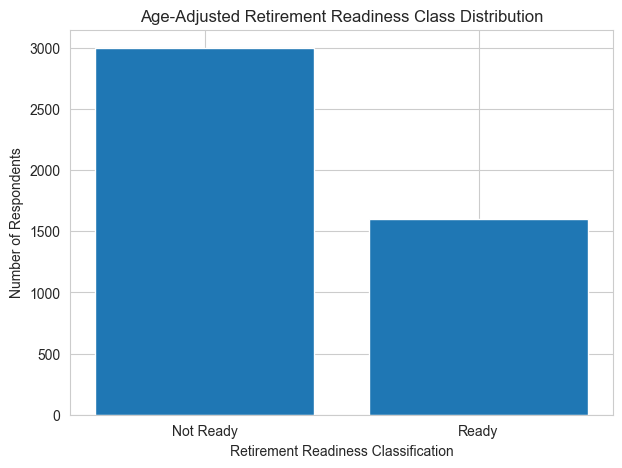

In [46]:
plt.figure(figsize=(7, 5))

ret_ready_counts = df["RET_READY"].value_counts().sort_index()
ret_ready_labels = ["Not Ready", "Ready"]

plt.bar(ret_ready_labels, ret_ready_counts.values)

plt.title("Age-Adjusted Retirement Readiness Class Distribution")
plt.xlabel("Retirement Readiness Classification")
plt.ylabel("Number of Respondents")

plt.show()

The age-adjusted retirement readiness target is imbalanced, with most respondents classified as not retirement ready. This supports the use of class-weighted classification models and class-specific evaluation metrics such as precision, recall, and F1-score.

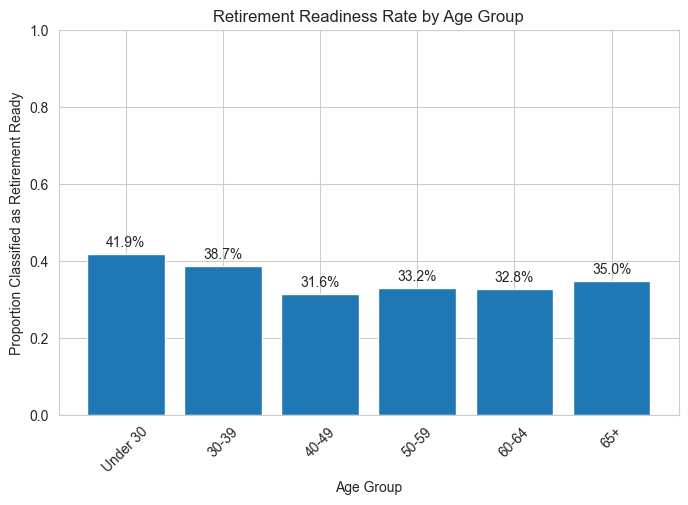

In [47]:
readiness_by_age = (
    df.groupby("AGE_GROUP")["RET_READY"]
      .mean()
      .reindex(["Under 30", "30-39", "40-49", "50-59", "60-64", "65+"])
)

plt.figure(figsize=(8, 5))

bars = plt.bar(readiness_by_age.index, readiness_by_age.values)

plt.title("Retirement Readiness Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion Classified as Retirement Ready")
plt.ylim(0, 1)

plt.xticks(rotation=45)

# Add percentage labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.1%}",
        ha="center",
        va="bottom"
    )

plt.show()

This chart shows the proportion of respondents classified as retirement ready within each age group. Because the readiness threshold increases with age, the chart helps evaluate how the age-adjusted classification rule behaves across different life stages.

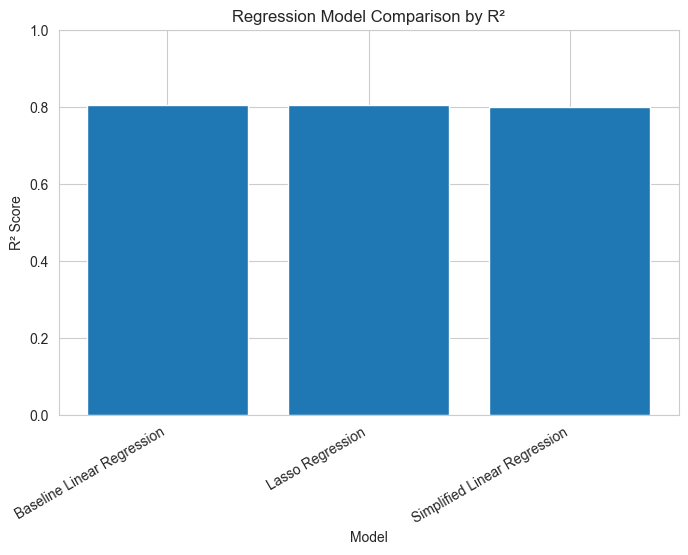

In [48]:
model_comparison_plot = model_comparison.copy()

plt.figure(figsize=(8, 5))

plt.bar(model_comparison_plot["Model"], model_comparison_plot["R2"])

plt.title("Regression Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.xticks(rotation=30, ha="right")

plt.show()

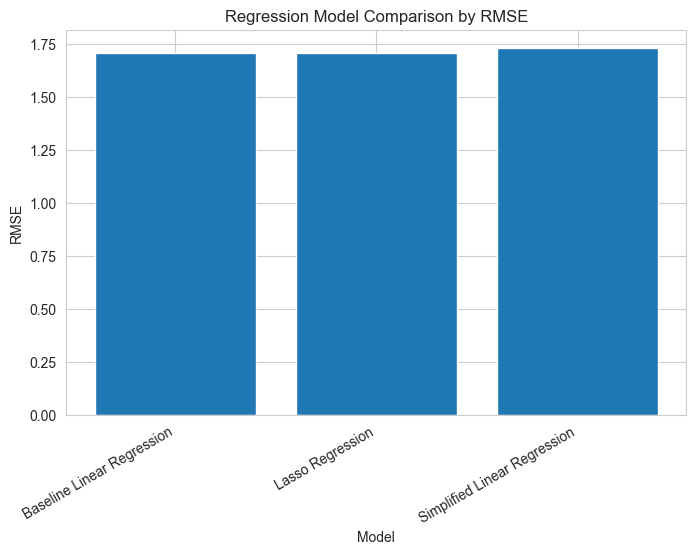

In [49]:
plt.figure(figsize=(8, 5))

plt.bar(model_comparison_plot["Model"], model_comparison_plot["RMSE"])

plt.title("Regression Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30, ha="right")

plt.show()

The regression model comparison shows that all three models performed similarly, with RMSE values around 1.7. The baseline Linear Regression and Lasso Regression models had nearly identical error rates, indicating that regularization did not substantially improve prediction accuracy. The Simplified Linear Regression model had a slightly higher RMSE, but the difference was small, suggesting that the reduced feature set still captured most of the predictive value. Overall, the simplified model may be useful for interpretation, while the full baseline and Lasso models provide slightly stronger predictive performance.

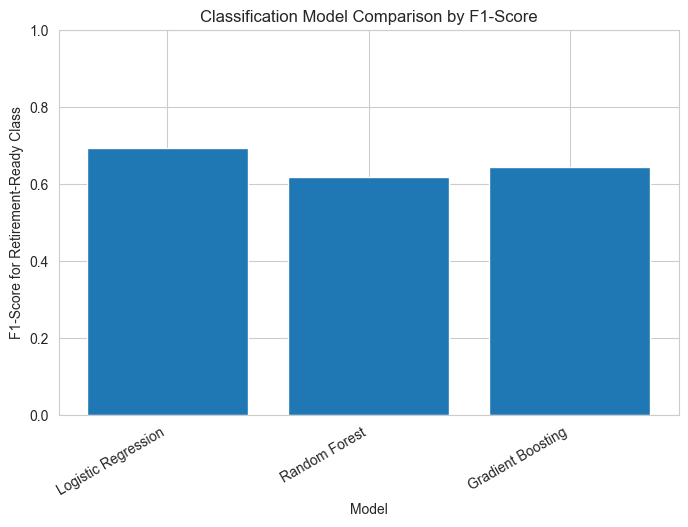

In [50]:
classification_plot = classification_model_comparison.copy()

plt.figure(figsize=(8, 5))

plt.bar(classification_plot["Model"], classification_plot["F1"])

plt.title("Classification Model Comparison by F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score for Retirement-Ready Class")
plt.ylim(0, 1)

plt.xticks(rotation=30, ha="right")

plt.show()

The classification model comparison shows that Logistic Regression produced the highest F1-score for the retirement-ready class at approximately 0.69. Gradient Boosting had the second-highest F1-score at approximately 0.64, while Random Forest had the lowest F1-score at approximately 0.62. This suggests that Logistic Regression provided the best balance between precision and recall for identifying retirement-ready respondents.

Although Random Forest and Gradient Boosting had slightly higher overall accuracy than Logistic Regression, their lower F1-scores indicate weaker balance when predicting the ready class. Since the dataset remains moderately imbalanced, F1-score is useful because it accounts for both false positives and false negatives. Based on this comparison, Logistic Regression appears to be the strongest classifier for identifying retirement-ready respondents, while Gradient Boosting provides the best overall accuracy.

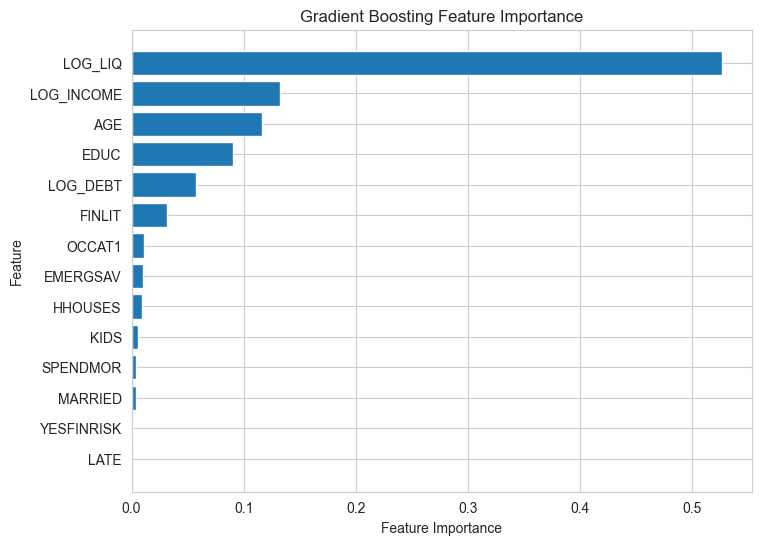

In [51]:
gb_importance = pd.Series(
    gb_clf.feature_importances_,
    index=classification_features
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))

plt.barh(gb_importance.index, gb_importance.values)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

The Gradient Boosting feature importance plot identifies which variables contributed most to the preferred classification model. These results help explain which financial and demographic factors were most useful for predicting whether respondents met the age-adjusted retirement readiness threshold.

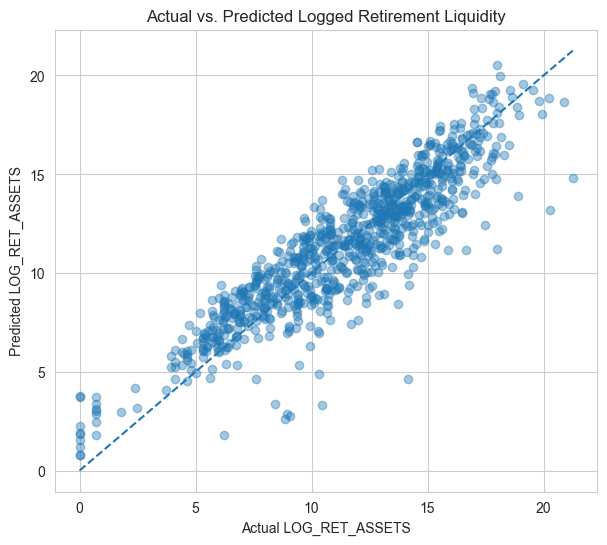

In [52]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Actual vs. Predicted Logged Retirement Liquidity")
plt.xlabel("Actual LOG_RET_ASSETS")
plt.ylabel("Predicted LOG_RET_ASSETS")

plt.show()

The actual versus predicted plot shows that the regression model generally predicted `LOG_RET_ASSETS` well. Most points follow the diagonal reference line, indicating that predicted values were close to actual values for many respondents. This supports the strong regression performance shown by the model's R² and RMSE values.

However, the plot also shows more spread at the lower and higher ends of `LOG_RET_ASSETS`. Some respondents with very low actual retirement assets were predicted to have higher values, while a few high-asset respondents were underpredicted. This suggests that the model captures the overall pattern well but has more difficulty with extreme cases and households with unusual financial profiles.

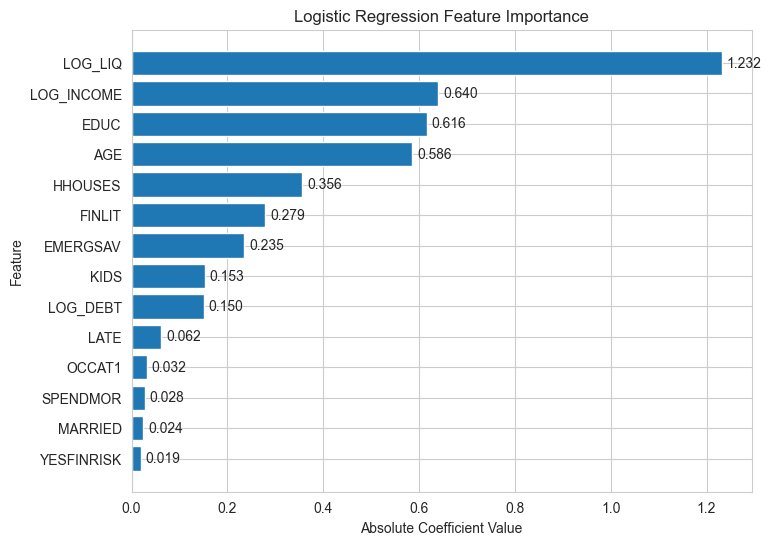

In [53]:
log_coef = pd.Series(
    log_clf.named_steps["model"].coef_[0],
    index=classification_features
)

log_importance = log_coef.abs().sort_values(ascending=True)

plt.figure(figsize=(8, 6))

bars = plt.barh(log_importance.index, log_importance.values)

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.show()

In [54]:
log_coef_df = pd.DataFrame({
    "Feature": log_coef.index,
    "Coefficient": log_coef.values,
    "Absolute Importance": log_coef.abs().values,
    "Direction": np.where(log_coef.values > 0, "Positive", "Negative")
}).sort_values("Absolute Importance", ascending=False)

log_coef_df

,Feature,Coefficient,Absolute Importance,Direction
0,LOG_LIQ,1.232246,1.232246,Positive
2,LOG_INCOME,-0.639910,0.639910,Negative
1,EDUC,0.616043,0.616043,Positive
4,AGE,-0.586296,0.586296,Negative
3,HHOUSES,0.356159,0.356159,Positive
5,FINLIT,0.278715,0.278715,Positive
6,EMERGSAV,0.234993,0.234993,Positive
7,KIDS,-0.153237,0.153237,Negative
11,LOG_DEBT,-0.150435,0.150435,Negative
13,LATE,-0.061752,0.061752,Negative


The Logistic Regression feature importance results show that `LOG_LIQ` was the most influential predictor in the classification model. This supports the importance of liquidity in predicting retirement readiness and aligns directly with Research Question 2. `LOG_INCOME`, education, age, homeownership, financial literacy, and emergency savings also had relatively large absolute coefficient values, suggesting that both financial resources and socioeconomic factors contributed meaningfully to the classification of respondents as ready or not ready.

The coefficient direction table provides additional context for how each variable influenced the model. Positive coefficients such as `LOG_LIQ`, `EDUC`, `HHOUSES`, `FINLIT`, and `EMERGSAV` increased the likelihood of being classified as retirement ready. Negative coefficients such as `LOG_INCOME`, `AGE`, `LOG_DEBT`, `KIDS`, `LATE`, `MARRIED`, and `OCCAT1` decreased the likelihood of being classified as ready. The negative coefficient for `LOG_DEBT` supports the idea that higher debt is associated with lower retirement readiness, while the negative signs for `AGE`, `LOG_INCOME`, and `MARRIED` should be interpreted carefully because the readiness threshold is age- and income-adjusted and categorical coding may affect direction.

ROC-AUC was used as an additional evaluation metric to assess each model’s ability to distinguish between respondents who were retirement ready and those who were not. Unlike accuracy, ROC-AUC evaluates model performance across different classification thresholds. However, because the retirement-ready class was much smaller than the not-ready class, precision, recall, F1-score, and the confusion matrix remained more important for interpreting practical classification performance.

In [55]:
# probabilities for the positive class: RET_READY = 1
y_prob_log = log_clf.predict_proba(X_test_cls)[:, 1]
y_prob_rf = rf_clf.predict_proba(X_test_cls)[:, 1]
y_prob_gb = gb_clf.predict_proba(X_test_cls)[:, 1]

auc_log = roc_auc_score(y_test_cls, y_prob_log)
auc_rf = roc_auc_score(y_test_cls, y_prob_rf)
auc_gb = roc_auc_score(y_test_cls, y_prob_gb)

roc_auc_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC_AUC": [auc_log, auc_rf, auc_gb]
})

roc_auc_comparison

,Model,ROC_AUC
0,Logistic Regression,0.835481
1,Random Forest,0.831430
2,Gradient Boosting,0.843901


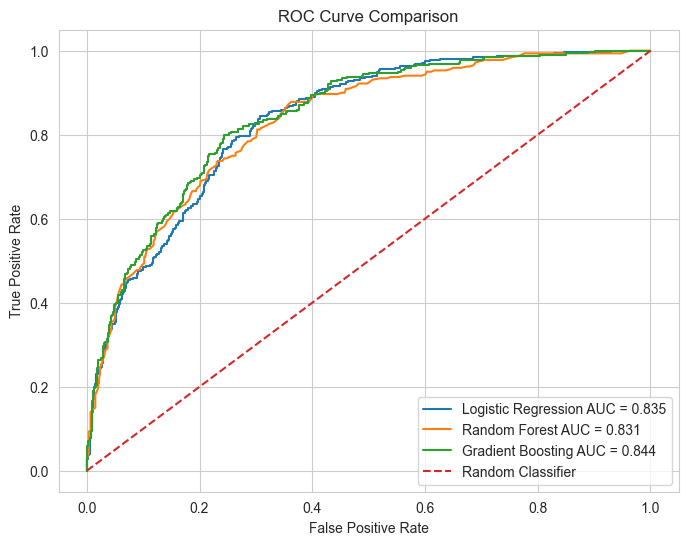

In [56]:
fpr_log, tpr_log, _ = roc_curve(y_test_cls, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test_cls, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test_cls, y_prob_gb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {auc_log:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.3f}")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting AUC = {auc_gb:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

The ROC-AUC results show that all three classification models performed well above the random-classifier baseline. Gradient Boosting produced the highest ROC-AUC score at approximately 0.844, followed by Logistic Regression at 0.835 and Random Forest at 0.831. This suggests that all three models were reasonably effective at distinguishing between retirement-ready and not-ready respondents.

The ROC curve comparison shows that the model curves remain well above the diagonal random-classifier line across most threshold values. Although Gradient Boosting had the strongest overall AUC, the three models performed similarly. Combined with the earlier classification metrics, Gradient Boosting appears to provide the strongest overall discrimination, while Logistic Regression remains useful because of its interpretability and stronger F1-score for the retirement-ready class.

In [57]:
df.to_csv("../data/final/final_data.csv", index=False)

### Ad hoc code to produce extra data visualizations

In [77]:
classification_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test_cls, y_pred_log),
        accuracy_score(y_test_cls, y_pred_rf),
        accuracy_score(y_test_cls, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test_cls, y_pred_log, zero_division=0),
        precision_score(y_test_cls, y_pred_rf, zero_division=0),
        precision_score(y_test_cls, y_pred_gb, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test_cls, y_pred_log, zero_division=0),
        recall_score(y_test_cls, y_pred_rf, zero_division=0),
        recall_score(y_test_cls, y_pred_gb, zero_division=0)
    ],
    "F1": [
        f1_score(y_test_cls, y_pred_log, zero_division=0),
        f1_score(y_test_cls, y_pred_rf, zero_division=0),
        f1_score(y_test_cls, y_pred_gb, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_cls, y_prob_log),
        roc_auc_score(y_test_cls, y_prob_rf),
        roc_auc_score(y_test_cls, y_prob_gb)
    ]
})

classification_model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.756,0.618,0.788,0.692,0.835
1,Random Forest,0.765,0.711,0.547,0.618,0.831
2,Gradient Boosting,0.774,0.712,0.588,0.644,0.844


In [78]:
feature_name_map = {
    "LOG_LIQ": "Liquidity",
    "EDUC": "Education",
    "LOG_INCOME": "Income",
    "HHOUSES": "Home Ownership",
    "AGE": "Age",
    "FINLIT": "Financial Literacy",
    "EMERGSAV": "Emergency Savings",
    "KIDS": "Children",
    "MARRIED": "Married",
    "OCCAT1": "Occupation Category",
    "YESFINRISK": "Financial Risk Tolerance",
    "LOG_DEBT": "Debt",
    "SPENDMOR": "Spends More Than Income",
    "LATE": "Late Payments"
}

features = X_train_cls.columns

# Logistic Regression importance: absolute coefficient values
lr_importance = np.abs(np.ravel(lr.coef_))

# Random Forest and Gradient Boosting importance
rf_importance = rf_clf.feature_importances_
gb_importance = gb_clf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Logistic Regression": lr_importance,
    "Random Forest": rf_importance,
    "Gradient Boosting": gb_importance
})

# Rename features
importance_df["Feature"] = importance_df["Feature"].replace(feature_name_map)

# Normalize each model's importance so they are comparable on a 0–1 scale
for col in ["Logistic Regression", "Random Forest", "Gradient Boosting"]:
    importance_df[col] = importance_df[col] / importance_df[col].max()

# Optional: create average importance across all three models
importance_df["Average Importance"] = importance_df[
    ["Logistic Regression", "Random Forest", "Gradient Boosting"]
].mean(axis=1)

# Sort by average importance
importance_df = importance_df.sort_values("Average Importance", ascending=False)

importance_df.round(3)

,Feature,Logistic Regression,Random Forest,Gradient Boosting,Average Importance
0,Liquidity,1.000,1.000,1.000,1.000
6,Emergency Savings,0.946,0.111,0.019,0.359
4,Age,0.339,0.505,0.220,0.355
2,Income,0.008,0.708,0.251,0.322
1,Education,0.329,0.448,0.173,0.316
11,Debt,0.101,0.433,0.110,0.214
7,Children,0.487,0.135,0.010,0.211
8,Married,0.309,0.070,0.007,0.129
3,Home Ownership,0.221,0.078,0.017,0.105
9,Occupation Category,0.138,0.122,0.021,0.094


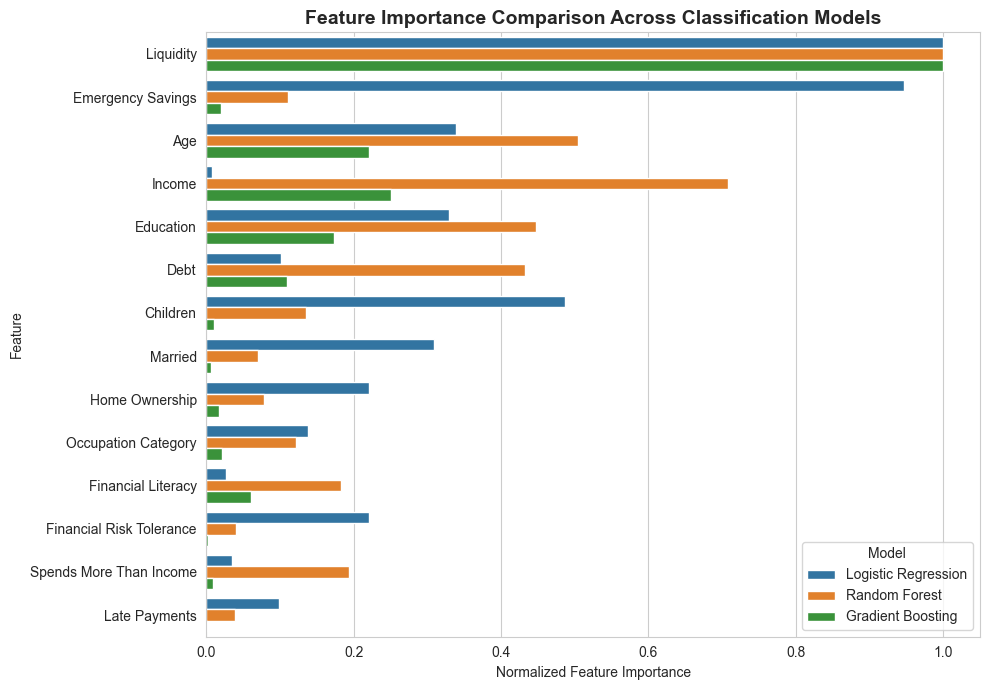

In [79]:
plot_df = importance_df.melt(
    id_vars="Feature",
    value_vars=["Logistic Regression", "Random Forest", "Gradient Boosting"],
    var_name="Model",
    value_name="Normalized Importance"
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=plot_df,
    x="Normalized Importance",
    y="Feature",
    hue="Model"
)

plt.title("Feature Importance Comparison Across Classification Models", fontsize=14, fontweight="bold")
plt.xlabel("Normalized Feature Importance")
plt.ylabel("Feature")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

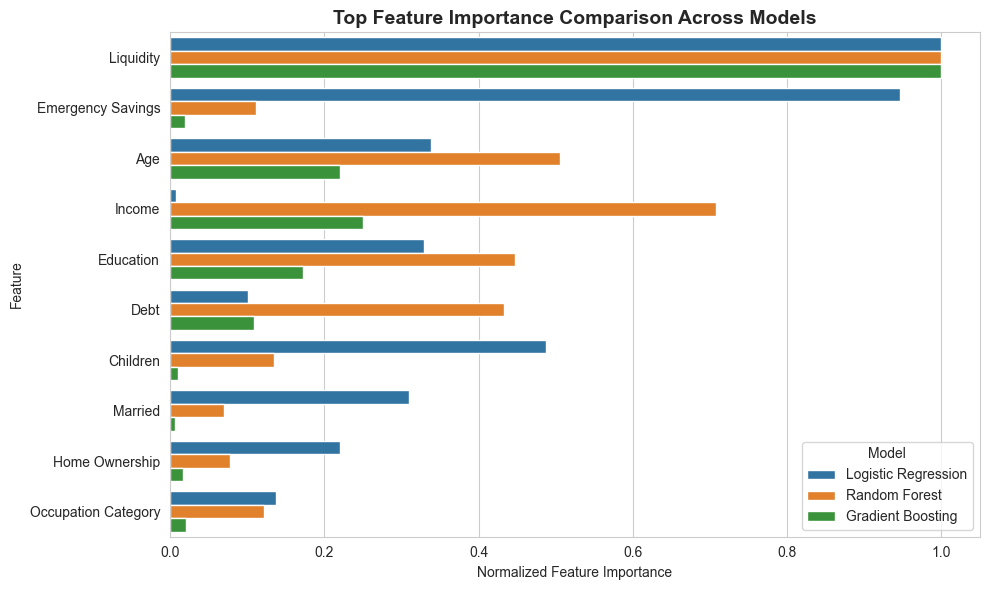

In [80]:
top_features = importance_df.head(10)["Feature"]

plot_df_top = plot_df[plot_df["Feature"].isin(top_features)]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_df_top,
    x="Normalized Importance",
    y="Feature",
    hue="Model",
    order=top_features
)

plt.title("Top Feature Importance Comparison Across Models", fontsize=14, fontweight="bold")
plt.xlabel("Normalized Feature Importance")
plt.ylabel("Feature")
plt.legend(title="Model")

plt.tight_layout()
plt.show()

In [83]:
dt_clf = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=25,
    class_weight="balanced",
    random_state=42
)

dt_clf.fit(X_train_cls, y_train_cls)

# Predictions
y_pred_dt = dt_clf.predict(X_test_cls)
y_prob_dt = dt_clf.predict_proba(X_test_cls)[:, 1]

# Performance metrics
dt_results = {
    "Accuracy": accuracy_score(y_test_cls, y_pred_dt),
    "Precision": precision_score(y_test_cls, y_pred_dt, zero_division=0),
    "Recall": recall_score(y_test_cls, y_pred_dt, zero_division=0),
    "F1": f1_score(y_test_cls, y_pred_dt, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_cls, y_prob_dt)
}

dt_results

{'Accuracy': 0.7399347116430903,
 'Precision': 0.6046511627906976,
 'Recall': 0.73125,
 'F1': 0.6619519094766619,
 'ROC-AUC': 0.7800839941569282}

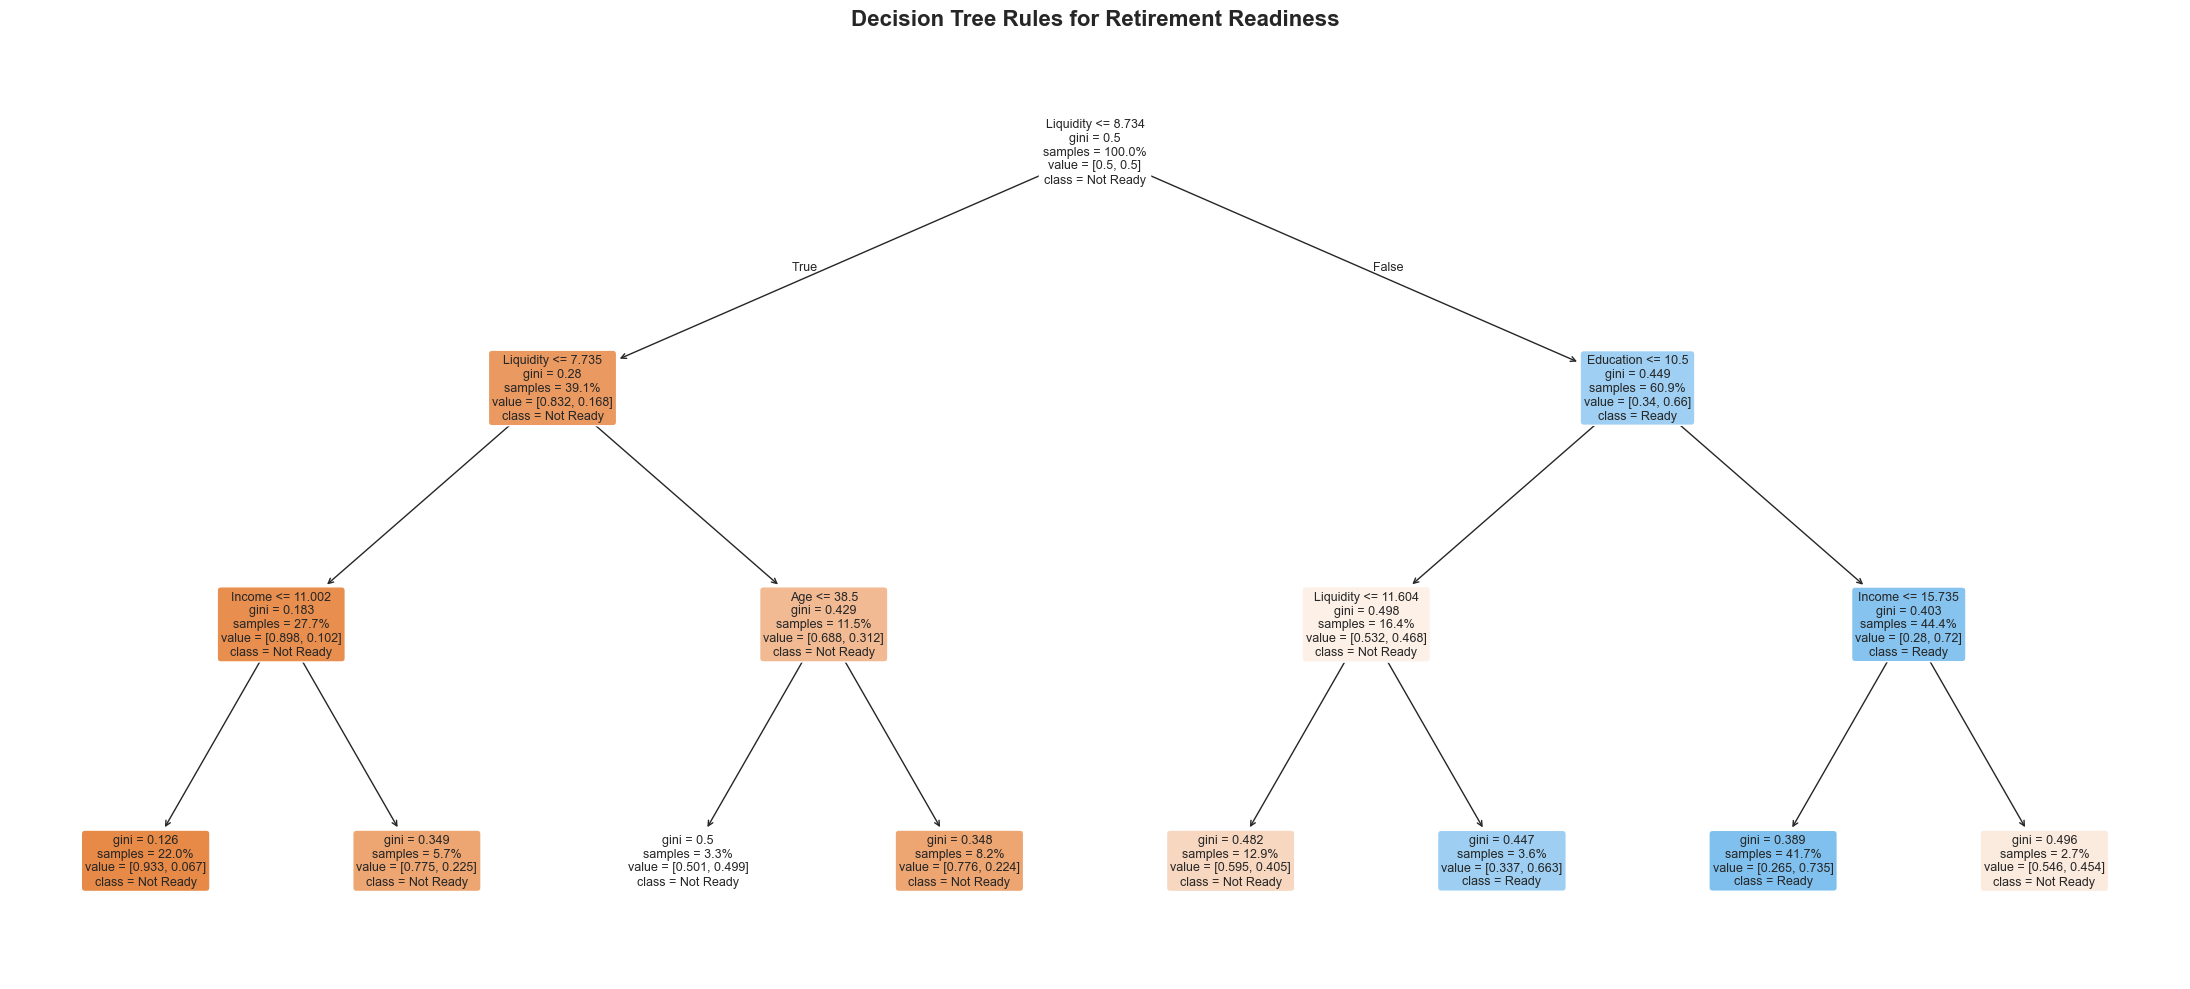

In [87]:
feature_names = [
    feature_name_map.get(col, col) for col in X_train_cls.columns
]

plt.figure(figsize=(22, 10))

plot_tree(
    dt_clf,
    feature_names=feature_names,
    class_names=["Not Ready", "Ready"],
    filled=True,
    rounded=True,
    fontsize=9,
    proportion=True
)

plt.title("Decision Tree Rules for Retirement Readiness", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()